# Obtaining & exploring dataset

In [24]:
import numpy as np
import pandas as pd
import torch

In [25]:
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from pts.model.tempflow import TempFlowEstimator
from pts.model.transformer_tempflow import TransformerTempFlowEstimator
from pts import Trainer
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator
from gluonts.dataset.util import to_pandas
import matplotlib.pyplot as plt

In [26]:
dataset = get_dataset("traffic_nips", regenerate=False)


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [28]:
device

device(type='cuda')


## Prepare dataset

In [29]:
train_grouper = MultivariateGrouper(max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

test_grouper = MultivariateGrouper(num_test_dates=int(len(dataset.test)/len(dataset.train)),
                                   max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

In [30]:
dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:106: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  timestamp + (len(data[FieldName.TARGET]) - 1) * timestamp.freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:108: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self.frequency = timestamp.freq
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:217: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  freq=data[FieldName.START].freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:166: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  freq=data[FieldName.START].freq,
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\multivariate_grouper.py:177: FutureWarning: Timestamp.

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\util.py:136: FutureWarning: Timestamp.freqstr is deprecated and will be removed in a future version.
  freq = start.freqstr


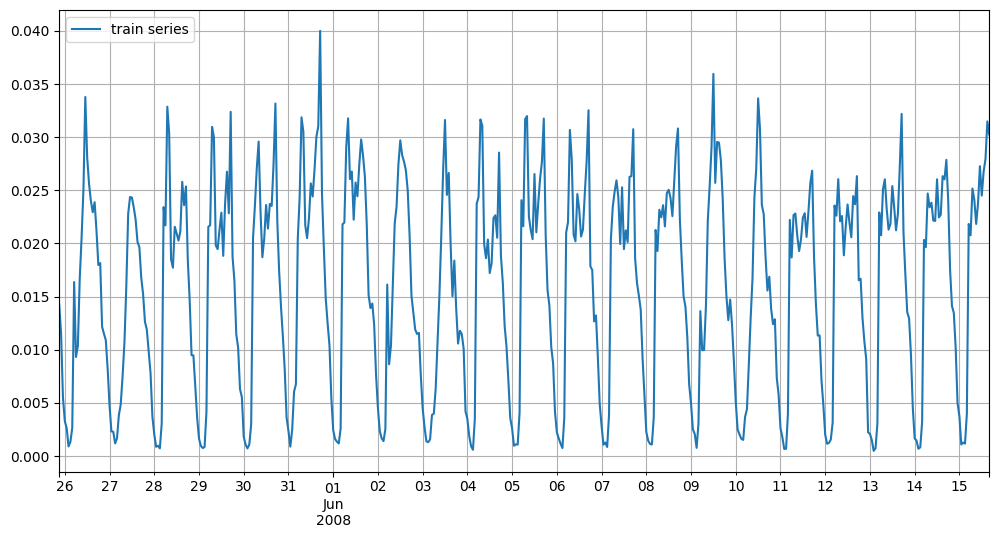

In [31]:
# Training dataset plot:

entry = next(iter(dataset.train))
train_series = to_pandas(entry)

plt.figure(figsize=(12, 6))

train_series[-500:].plot() # Plot de los 500 ultimos (es mucho toda la serie)
plt.grid(which="both")
plt.legend(["train series"], loc="upper left")
plt.show()


C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\dataset\util.py:136: FutureWarning: Timestamp.freqstr is deprecated and will be removed in a future version.
  freq = start.freqstr


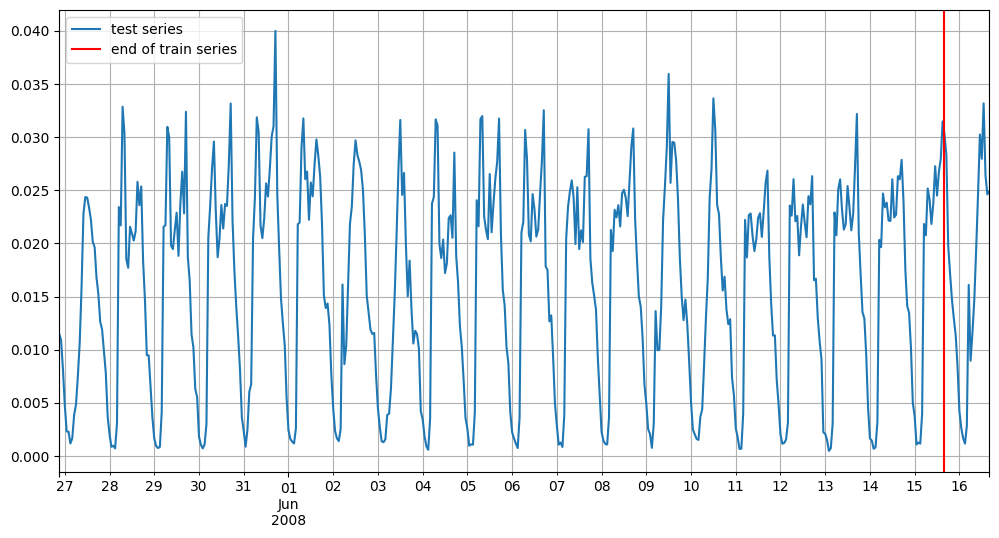

In [32]:
entry = next(iter(dataset.test))
test_series = to_pandas(entry)

plt.figure(figsize=(12, 6))

test_series[-500:].plot()
plt.axvline(train_series.index[-1], color="r")  # end of train dataset
plt.grid(which="both")
plt.legend(["test series", "end of train series"], loc="upper left")
plt.show()

In [33]:
print(
    f"Length of forecasting window in test dataset: {len(test_series) - len(train_series)}"
)
print(f"Recommended prediction horizon: {dataset.metadata.prediction_length}")
print(f"Frequency of the time series: {dataset.metadata.freq}")

Length of forecasting window in test dataset: -1
Recommended prediction horizon: 24
Frequency of the time series: H


## Evaluator

In [34]:
evaluator = MultivariateEvaluator(quantiles=(np.arange(20)/20.0)[1:],
                                  target_agg_funcs={'sum': np.sum})

## Modelo

In [35]:
#input_size=taget_dim+target_dim*len(lags_seq)+len(time_feat)
#target=137, len(lags_seq)=3, and len(time_feat)=4, so the input_size=137+137x3+4=552

In [ ]:
#Para traffic dataset 3452, para solar nips 552 el input_size
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='LSTM',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    n_blocks=5,
    trainer=Trainer(device=device,
                    epochs=2,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64,
                    num_workers = 8)
)

In [36]:
#traffic
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=1,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)


In [37]:
predictor = estimator.train(dataset_train, prefetch_factor = None)

  0%|          | 0/99 [00:00<?, ?it/s]

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:343: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self._freq_base = start.freq.base
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\split.py:36: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  return _shift_timestamp_helper(ts, ts.freq, offset)
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:384: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  ..., i0 : i0 + length * start.freq.n : start.freq.n
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:340: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self._freq_base is None or self._freq_base == start.freq.base
100%|██████████| 99/99 [00:28<00:00,  3.51it/s, epoch=1/1, avg_loss=115]   


# Samples

In [15]:
from pathlib import Path
from typing import Iterator, List, Optional

import numpy as np
import torch
import torch.nn as nn

from gluonts.core.serde import dump_json, load_json
from gluonts.dataset.common import Dataset
from gluonts.dataset.loader import InferenceDataLoader
from gluonts.model.forecast import Forecast
from gluonts.model.forecast_generator import (
    ForecastGenerator,
    SampleForecastGenerator,
    predict_to_numpy,
)
from gluonts.model.predictor import OutputTransform, Predictor
from gluonts.torch.batchify import batchify
from gluonts.torch.component import equals
from gluonts.transform import Transformation

#from gluonts.itertools import select
from gluonts.model.forecast import Forecast, QuantileForecast, SampleForecast
from functools import singledispatch

In [ ]:
# esto se utiliza en otros modelos de gluonts para  guardar y cargar un modelo. No me funciono con el NF temporal, pero probar mas adelante.
from pathlib import Path

predictor.serialize(Path("/content/"))

from gluonts.model.predictor import Predictor


predictor_deserialized = Predictor.deserialize(Path("/content/"))

In [41]:
#Aqui hare el codigo para sacar las muestras por mi cuenta. sin el uso de la función make evaluation predictions
prediction_length = predictor.prediction_length
lead_time = predictor.lead_time
freq = predictor.freq

# CODIGO PERTENECIENTE A FUNCION MAKE EVALUATION PREDICTIONS:

from typing import Dict, Iterator, NamedTuple, Optional, Tuple
from gluonts.dataset.common import DataEntry, Dataset
def add_ts_dataframe(
        data_iterator: Iterator[DataEntry],
    ) -> Iterator[DataEntry]:
        for data_entry in data_iterator:
            data = data_entry.copy()
            index = pd.date_range(
                start=data["start"],
                freq=freq,
                periods=data["target"].shape[-1],
            )
            data["ts"] = pd.DataFrame(
                index=index, data=data["target"].transpose()
            )
            yield data

def ts_iter(dataset: Dataset) -> pd.DataFrame:
        for data_entry in add_ts_dataframe(iter(dataset)):
            yield data_entry["ts"]


def truncate_target(data):
        data = data.copy()
        target = data["target"]
        assert (
            target.shape[-1] >= prediction_length
        )  # handles multivariate case (target_dim, history_length)
        data["target"] = target[..., : -prediction_length - lead_time]
        return data

from gluonts.transform import AdhocTransform
dataset_trunc = AdhocTransform(truncate_target).apply(dataset_test)

forecast_it, ts_it = predictor.predict(dataset_trunc, num_samples=2), ts_iter(dataset_test)
forecasts = list(forecast_it)
targets = list(ts_it)



C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:340: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  self._freq_base is None or self._freq_base == start.freq.base
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\split.py:36: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  return _shift_timestamp_helper(ts, ts.freq, offset)
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\transform\feature.py:384: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  ..., i0 : i0 + length * start.freq.n : start.freq.n


In [42]:
forecasts[0].log_prob

array([[-153.10281],
       [-213.57864]], dtype=float32)

In [15]:
type(forecasts)

list

In [16]:
len(forecasts)

7

In [19]:
forecasts[0].samples.shape

(2, 24, 963)

In [23]:
forecasts[0].log_prob

array([[325.1833 ],
       [191.38593]], dtype=float32)

In [25]:
len(forecasts[6])

2

In [30]:
predictor.prediction_net.target_dim

963

In [37]:
forecasts[0][0]

C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\core\serde\pd.py:31: FutureWarning: Timestamp.freq is deprecated and will be removed in a future version.
  "kwargs": {"freq": v.freqstr if v.freq else None},
C:\Users\shesh\Documents\GluonTS\ModGluonTS\src\gluonts\core\serde\pd.py:31: FutureWarning: Timestamp.freqstr is deprecated and will be removed in a future version.
  "kwargs": {"freq": v.freqstr if v.freq else None},


gluonts.model.forecast.SampleForecast(freq="H", info=None, item_id=None, samples=numpy.array([[[1.8002439737319946, 1.3072912693023682, 3.2406504154205322, 2.050356149673462, 1.6910426616668701, 2.080731153488159, 1.5775880813598633, 1.4853765964508057, 2.0709011554718018, 1.6411774158477783, 1.4933289289474487, 1.7499027252197266, 2.1611878871917725, 1.4655306339263916, 4.184672832489014, 2.5735363960266113, 2.511972427368164, 2.0636544227600098, 2.904672622680664, 2.3139896392822266, 3.4270925521850586, 1.0611649751663208, 1.5681060552597046, 1.9553900957107544, 1.6423068046569824, 1.431278109550476, 1.5453697443008423, 1.4972686767578125, 1.6547943353652954, 1.8777996301651, 1.8376911878585815, 2.520087718963623, 1.5240141153335571, 0.940649688243866, 2.417863368988037, 1.6977531909942627, 2.340766191482544, 1.7974382638931274, 2.1907131671905518, 3.3056631088256836, 2.852876901626587, 2.8846468925476074, 3.6565985679626465, 1.8796937465667725, 1.758213758468628, 6.10914421081543, 2

In [24]:
log_px = forecasts[0][-1]
muestras = forecasts[0][0]

In [25]:
type(muestras)

gluonts.model.forecast.SampleForecast

In [27]:
muestras.samples.shape

(2, 24, 963)

In [20]:
len(log_px)

24

In [23]:
log_px[1].shape

torch.Size([700, 1, 1])

In [21]:
log_px.reshape(
            (
                -1,
                predictor.prediction_net.num_parallel_samples,
                predictor.prediction_net.prediction_length,
                predictor.prediction_net.target_dim,
            ))

ValueError: cannot reshape array of size 16800 into shape (100,24,963)

In [ ]:
#predictor.predict



In [15]:
predictor.prediction_net

pts.model.tempflow.tempflow_network.TempFlowPredictionNetwork(cardinality=[1], cell_type="GRU", conditioning_length=200, context_length=24, dequantize=False, dropout_rate=0.3, embedding_dimension=5, flow_type="MAF", hidden_size=100, history_length=192, input_size=3856, lags_seq=[1, 24, 168], n_blocks=3, n_hidden=2, num_cells=128, num_layers=2, prediction_length=24, scaling=True, target_dim=963)

In [20]:
#Cuando hace predict llama al forecast_generator de gluonts.

# Codigo perteneciente al forecast_generator
num_samples = 2
input_names = predictor.input_names
prediction_net = predictor.prediction_net.to(device)
batch_size = predictor.batch_size
input_transform = predictor.input_transform
forecast_generator = predictor.forecast_generator
output_transform = predictor.output_transform
freq = "1H"

@singledispatch
def to_numpy(x) -> np.ndarray:
    raise NotImplementedError

@predict_to_numpy.register(nn.Module)
def _(prediction_net: nn.Module, inputs: torch.Tensor) -> np.ndarray:
    return prediction_net(*inputs).cpu().numpy()

inference_data_loader = InferenceDataLoader(
            dataset_test,
            transform=input_transform,
            batch_size=batch_size,
            stack_fn=lambda data: batchify(data, device),
        )

prediction_net.eval()



def sampleforecast(inference_dataloader, prediction_net, input_names, freq, output_transform, num_samples):
  for batch in inference_dataloader:
    inputs = [batch[k] for k in input_names]
    outputs = predict_to_numpy(prediction_net, inputs)

    if output_transform is not None:
      outputs = output_transform(batch, outputs)

    if num_samples:
      num_collected_samples = outputs[0].shape[0]
      collected_samples = [outputs]
      while num_collected_samples < num_samples:
        outputs = predict_to_numpy(prediction_net, inputs)
        if output_transform is not None:
            outputs = output_transform(batch, outputs)
        collected_samples.append(outputs)
        num_collected_samples += outputs[0].shape[0]
        outputs = [
            np.concatenate(s)[:num_samples]
            for s in zip(*collected_samples)
        ]
        assert len(outputs[0]) == num_samples

    i = -1
    forecast_results = []

    for i, output in enumerate(outputs):
      yield SampleForecast(
                    output,
                    start_date=batch["forecast_start"][i],
                    freq=freq,
                    item_id=batch[FieldName.ITEM_ID][i] if FieldName.ITEM_ID in batch else None,
                    info=batch["info"][i] if "info" in batch else None,
                )

    assert i + 1 == len(batch["forecast_start"])



forecast_it = sampleforecast(inference_dataloader=inference_data_loader,
                prediction_net=prediction_net,
                input_names=input_names,
                freq=freq,
                output_transform=output_transform,
                num_samples=num_samples)



In [ ]:
forecasts = list(forecast_it)

In [ ]:
#Codigo para obtener las muestras automaticamente.
forecast_it, ts_it = make_evaluation_predictions(dataset=dataset_test,
                                             predictor=predictor,
                                           num_samples=3)
forecasts = list(forecast_it)
targets = list(ts_it)

agg_metric, _ = evaluator(targets, forecasts, num_series=len(dataset_test))

def plot(target, forecast, prediction_length, prediction_intervals=(50.0, 90.0), color='g', fname=None):
    label_prefix = ""
    rows = 5
    cols = 5
    fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
    axx = axs.ravel()
    seq_len, target_dim = target.shape

    ps = [50.0] + [
            50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
        ]

    percentiles_sorted = sorted(set(ps))

    def alpha_for_percentile(p):
        return (p / 100.0) ** 0.3

    for dim in range(0, min(rows * cols, target_dim)):
        ax = axx[dim]

        target[-2 * prediction_length :][dim].plot(ax=ax)

        ps_data = [forecast.quantile(p / 100.0)[:,dim] for p in percentiles_sorted]
        i_p50 = len(percentiles_sorted) // 2

        p50_data = ps_data[i_p50]
        p50_series = pd.Series(data=p50_data, index=forecast.index)
        p50_series.plot(color=color, ls="-", label=f"{label_prefix}median", ax=ax)

        for i in range(len(percentiles_sorted) // 2):
            ptile = percentiles_sorted[i]
            alpha = alpha_for_percentile(ptile)
            ax.fill_between(
                forecast.index,
                ps_data[i],
                ps_data[-i - 1],
                facecolor=color,
                alpha=alpha,
                interpolate=True,
            )
            # Hack to create labels for the error intervals.
            # Doesn't actually plot anything, because we only pass a single data point
            pd.Series(data=p50_data[:1], index=forecast.index[:1]).plot(
                color=color,
                alpha=alpha,
                linewidth=10,
                label=f"{label_prefix}{100 - ptile * 2}%",
                ax=ax,
            )

    legend = ["observations", "median prediction"] + [f"{k}% prediction interval" for k in prediction_intervals][::-1]
    axx[0].legend(legend, loc="upper left")

    if fname is not None:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0.05)


import matplotlib.pyplot as plt
plot(
    target=targets[0],
    forecast=forecasts[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

muestras = forecasts[0].samples

primeraserie=muestras[:,:,0]
c =  10
primeraserie_ponderada = c*primeraserie

# Pruebas distribución


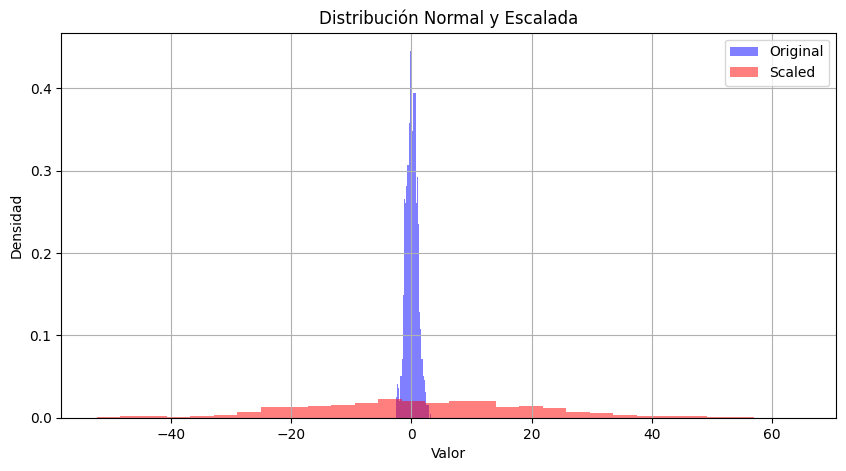

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generar muestras de una distribución normal con media 0 y desviación estándar 1
mu = 0
sigma = 1
sample_size = 1000
samples = np.random.normal(mu, sigma, sample_size)

# Graficar el histograma de las muestras originales
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=30, density=True, alpha=0.5, color='b', label='Original')

# Escalar las muestras
scaled_samples = samples * 20  # Escalar por un factor de 2

# Graficar el histograma de las muestras escaladas
plt.hist(scaled_samples, bins=30, density=True, alpha=0.5, color='r', label='Scaled')

plt.title('Distribución Normal y Escalada')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()